# Hands-on: Training a basic SST model with Anemoi

In this tutorial we will learn how to train an ML model to predict SST using the anemoi packages. To begin we will look at predicting SST from a 2 degree dataset, using SST at time t as input, to predict SST at time t + 1 day.

We will walk through some of the config choices in anemoi, and then run training on this simple model. There will then be the option to change some key parameters, and see how this impacts scores. By design the model is very simple, with a limited set of inputs and outputs, and small architecture. The focus isn't on predictive skill, but on exploring different design choices and their impact.

**Learning Objectives**
By the end of this tutorial, you will:
- Run a simple ML model to predict ocean SST one day ahead.
- Learn how to configure the anemoi training pipeline and make some simple changes
- Gain understanding of the impact of some key parameters

**Resources**
- [Anemoi Documentation](https://anemoi.readthedocs.io/projects/training/en/latest/)

## Setup

In [21]:
#ensure in the right dir if not already
current_dir = %pwd

if not current_dir.endswith("ToySSTProblem"):
    %cd ToySSTProblem

%pwd

'/home/student1/ToySSTProblem'

We need to ensure we are working in a suitable environment. Depending on your platform, this may already be set up for you. If it isn't, we have provided a requirements.txt file. This is compatible with python 3.11.10. To set your environment up, first load python version 3.11.10, then install the required libraries with
```
pip install -r requirements.txt
```
In a notebook you can uncomment out and run the below cell.

In [22]:
#!python3 -m pip install -r requirements.txt

In [23]:
# Import the necessary modules
import yaml
from omegaconf import OmegaConf
from pathlib import Path

import shutil
import os
import sys
import subprocess
from pathlib import Path
from IPython.display import display, Image

# Load our minimal configuration file
config_path = Path("./training_configs/ToySST.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import mlflow

import zarr, s3fs

%matplotlib inline

#### Obtain data

If working on EWC or Edito, you may already have access to the relevant data. Otherwise, a data.zarr file and a tarball with output from a pre-trained model are available on S3 cloud storage. Pull these if required; change the variable NeedData to True and run the below cells.

In [24]:
NeedData=True

In [25]:
## First pull the output from a pre-trained model, and change permissions.
## This should create a directory "pretrained_outputs" containing checkpoints, logs and plots

if NeedData:
    !curl -L https://object-store.os-api.cci1.ecmwf.int/ecmwf-training-nwp-ml/training_outputs.tgz | tar xz
    # rename to avoid confusion later
    old=Path("./training_outputs")
    new=Path("./pretrained_outputs")
    shutil.rmtree(new, ignore_errors=True)
    old.rename(new)
    old.mkdir(parents=True, exist_ok=True)
    shutil.copytree(new, old, dirs_exist_ok=True)
    shutil.rmtree(old, ignore_errors=True)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  684M  100  684M    0     0  86.6M      0  0:00:07  0:00:07 --:--:-- 96.9M


In [6]:
# Next pull the dataset in zarr format. This will create a file called ToySSTDataset.zarr

if NeedData:
    import zarr
    import s3fs
    
    s3 = s3fs.S3FileSystem(
        anon=True,
        client_kwargs={"endpoint_url": "https://object-store.os-api.cci1.ecmwf.int"}
    )
    
    store = s3fs.S3Map(
        root="s3://ecmwf-training-nwp-ml/ToySSTDataset.zarr",
        s3=s3,
        check=False
    )

    local_store = zarr.DirectoryStore("ToySSTDataset.zarr")

    # Overwrite existing contents
    zarr.copy_store(store, local_store, if_exists="replace")

    print("✅ Dataset copied to ToySSTDataset.zarr")

KeyboardInterrupt: 

## Building Our Training Config

We'll work in this notebook, first examining our training configuration, highlighting some key elements. 

The configs set up can be found in the directory training_configs. This is a collection of configuration files defining defaults for various top-level choices, along with a main config file, ToySST.yaml, which defines what is actually used.

We'll load this file and examine it section by section. This configration is combined with the defaults in the training_configs directory, to create the model and training set up. 

### 1: Default Configurations

The top-level decisions around training strategy and model design etc are all set in the defaults at the start of the config file. This is where we make decisions such as which archetecture to use, and which training strategy to use (i.e. deterministic prediction which is the default or and ensemble set up, an autoencoder etc). Here we see the defaults chosen for a Toy SST example.


In [26]:
# Display the default configuration section
print("Default Configurations:")
print("=" * 50)
print(yaml.dump(config['defaults'], default_flow_style=False))

Default Configurations:
- data: zarr
- dataloader: native_grid
- diagnostics: evaluation
- system: example
- graph: multi_scale
- model: graphtransformer
- training: default
- _self_



Here we have chosen to use the zarr and native grid options for data and dataloader, the standard evaluation diagnostics (other options include e.g. ensemble evaluation) a graph transformer architecture, with the multi-scale graph, and the default training option (this is designed for training a deterministic predictive model).

### Amendments to the default configuration files

Once these broad decisions are defined, more detailed choices are inhereted from the various yaml files within the training_configs directory. Specific changes to these defaults can be listed in the ToySST.yaml file to overwrite the standard options. Here we look at the amendments used for our toy SST example. (Bear in mind the defaults in anemoi relate, in most cases, to medium range weather forecast applications)

### 2: System Configuration

The system configuration (previously reffered to as hardware) defines decisions around the hardware options, such as the number of GPUs being used and how to distrubute these, the inputs (with their full paths) and the location for outputs.

In [27]:
# Display the hardware configuration section
print("Hardware Configuration:")
print("=" * 50)
print(yaml.dump(config['system'], default_flow_style=False))


Hardware Configuration:
hardware:
  accelerator: auto
  num_gpus_per_model: 1
  num_gpus_per_node: 1
  num_nodes: 1
input:
  dataset: ./ToySSTDataset.zarr
  graph: graph_${data.resolution}.pt
output:
  root: ./new_training_outputs



### 3: Data Configuration

The data configuration contains information on the data the model is trained on. It defines whether variables are forcing* (input only), prognostic (inputs and outputs), or diagnostic (output only). This sections also defined how variables are pre- and post-processed; what (if any) normalisation is applied etc. 

*Its important to note that here we do not use forcing in the classic ocean modelling sense, but instead referring to any variables which are input only, including static inputs such as the bathymetry, or land sea masks etc (though neither used in this toy example)

In [28]:
# Display the data configuration section
print("Data Configuration:")
print("=" * 50)
print(yaml.dump(config['data'], default_flow_style=False))


Data Configuration:
datasets:
  data:
    const_imputer:
      0:
      - sst
    diagnostic: []
    forcing:
    - cos_latitude
    - cos_longitude
    - sin_latitude
    - sin_longitude
    - cos_julian_day
    - cos_local_time
    - sin_julian_day
    - sin_local_time
    - insolation
    - 2t
    normalizer:
      default: mean-std
      none:
      - cos_latitude
      - cos_longitude
      - sin_latitude
      - sin_longitude
      - cos_julian_day
      - cos_local_time
      - sin_julian_day
      - sin_local_time
      - insolation
    processors:
      const_imputer:
        _target_: anemoi.models.preprocessing.imputer.ConstantImputer
        config: ${data.datasets.data.const_imputer}
      normalizer:
        _target_: anemoi.models.preprocessing.normalizer.InputNormalizer
        config: ${data.datasets.data.normalizer}
frequency: 24h
resolution: n48
timestep: 24h




The treatment of NaNs is defined -- here by imputing (filling nan values) with 0.

We define a number of variables which indicate the location, time of day and and time of year as forcing, along with 2 metre air temperature (2mT). There are no diagnostic (output only variables). All other variables are automatically defined as prognostic.

The way in which we nornalise data is defined. Setting the default as mean-std (so this is applied to any variables which aren't otherwise listed), and non normalisation ('None') is applied to a few specified variables (chosen because their values already span 0 to 1)

Information about the timestep of the model (i.e. what data spacing to take), the frequency of data available, and the resolution to use is given.

### 4: Dataloader Configuration

The dataloader defines what data to read in from the input files given in system, and how to read this in (batch sizes etc)


In [29]:
# Display the dataloader configuration section
print("Dataloader Configuration:")
print("=" * 50)
print(yaml.dump(config['dataloader'], default_flow_style=False))


Dataloader Configuration:
batch_size:
  test: 1
  training: 1
  validation: 1
dataset:
- dataset: ${system.input.dataset}
  end: 2024
  frequency: ${data.frequency}
  select:
  - 2t
  - sst
  - cos_julian_day
  - sin_julian_day
  - cos_local_time
  - sin_local_time
  - cos_longitude
  - sin_longitude
  - cos_latitude
  - sin_latitude
  - insolation
  start: 2020
limit_batches:
  training: 25
  validation: 25
num_workers:
  test: 1
  training: 1
  validation: 1
test:
  datasets:
    data:
      dataset: ${dataloader.dataset}
      end: 2024
      frequency: ${data.frequency}
      start: 2024
      trajectory: null
training:
  datasets:
    data:
      dataset: ${dataloader.dataset}
      end: 2022
      frequency: ${data.frequency}
      start: 2020
      trajectory: null
validation:
  datasets:
    data:
      dataset: ${dataloader.dataset}
      end: 2023
      frequency: ${data.frequency}
      start: 2023
      trajectory: null



For our toy example, we use batches of size 1.

We read in data from 2020 to 2024. Taking 2t (2m air temperature) from the atmospheric forcings dataset, and taking SST (avg_thetao_1), and various other inputs relating to location, timing etc, from the ocean dataset. 

We limit the model to just 10 batches per epoch (this is for computational speed for this toy example).

The train/val/test split is given as 2020-2022/2023/2024

### 5: Graph Configuration

The choice of graph, and whether this is used just for the encoder & decoder, or also used as the processor is defined in the default choices at the top.

Local changes generally include things like the graph shape and resolution

In [30]:
# Display the graph configuration section
print("Graph Configuration:")
print("=" * 50)
print(yaml.dump(config['graph'], default_flow_style=False))


Graph Configuration:
nodes:
  hidden:
    node_builder:
      resolution: 4



Here we change the resolution, giving us a fairly coarse grid. 

### 6: Model Configuration

Again the main decisions around what type of model (the architecture etc) are defined by the choice of model in the default configurations.

Local amendments often include the number of channels (i.e. the size and complexity of the model)

In [31]:
# Display the model configuration section
print("Model Configuration:")
print("=" * 50)
print(yaml.dump(config['model'], default_flow_style=False))


Model Configuration:
num_channels: 128



Here we define a relatively small number of channels for this toy problem, otherwise we take the default options for the graphtransformer model.

### 7: Training 

Here we define things about _how_ the model is trained. We configure the training parameters, strategy, and loss function used for training. 

In [32]:
# Display the training configuration section
print("Training Configuration:")
print("=" * 50)
print(yaml.dump(config['training'], default_flow_style=False))


Training Configuration:
lr:
  iterations: ${training.max_steps}
  min: 3e-7
  rate: 5e-4
  warmup: 500
max_epochs: 2
max_steps: 100000
metrics:
  datasets:
    data:
    - sst
training_loss:
  datasets:
    data:
      _target_: anemoi.training.losses.MSELoss
      ignore_nans: true
      scalers:
      - nan_mask_weights
      - node_weights



We set the learning rate schedule -- here the learning rate starts at 3e-7 and over 500 steps ????? NEED TO CLARIFY!!

The model is trained for only 2 epochs (usually this would be much larger, but it is kept very small for this toy problem), and with a maximum of 2500 steps (the model when the first of these limits is reached).

Metrics are calculated on the SST variable, avg_thetao_1.

The mean square error loss is used here. We ignore NaNs, so points which were originally NaNs (i.e the land in this ocean example) are not included in the loss. We also scale the loss based on ????????

### 8: Diagnostics Configuration

Here we define what diagnostics will be carried out. Decisions around where to log metrics and what metrics to log are inlcuded here.

In [33]:
# Display the diagnostics configuration section
print("Diagnostics Configuration:")
print("=" * 50)
print(yaml.dump(config['diagnostics'], default_flow_style=False))


Diagnostics Configuration:
log:
  mlflow:
    authentication: true
    enabled: true
    experiment_name: ToySST
    offline: true
    tracking_uri: file:${system.output.root}/logs/mlflow
plot:
  asynchronous: false
  callbacks:
  - _target_: anemoi.training.diagnostics.callbacks.plot.PlotLoss
    dataset_names:
    - data
    parameter_groups:
      surface_ocean:
      - sst
  - _target_: anemoi.training.diagnostics.callbacks.plot.PlotSample
    accumulation_levels_plot:
    - 0
    - 0.1
    - 0.5
    - 1
    - 1.5
    - 5
    - 10
    - 100
    colormaps: ${diagnostics.plot.colormaps}
    dataset_names:
    - data
    parameters: ${diagnostics.plot.parameters}
    per_sample: 6
    sample_idx: ${diagnostics.plot.sample_idx}
  datashader: false
  parameters:
  - sst



The first set of lines describes how to log the data, here we log to mlflow, with an experiment name 'ToySST', and a run name 'testing'. When developing models, multiple runs can be logged under the ToySST experiment name for easy comparison.

We then define the plots to produce. Here we first ask for plots of the loss over training, for the SST parameter (here this is the only predicted variable, but in other applications you can group sets of variables, i.e. all surface variables can form a group). We also ask for plots of sample predictions, again specifying the SST to be the only plotted parameter.

## Training Execution

Now that we have our configuration ready, let's execute the training. We'll run a short training session to verify everything works correctly. First we need to set a couple of environment variables (if running via a scheduler such as slurm these are taken from the slurm directives).

```bash
export ANEMOI_BASE_SEED=42
export ANEMOI_CONFIG_PATH="$PWD/training_configs"
```

We then use the following command to train the model:

```bash
anemoi-training train --config-name ToySST
```

The below cell initiates these commands within this notebook --- if working on the command line, the above would be sufficient.

In [34]:
cfg_dir = os.getcwd() + "/training_configs"

# Set environment variables
os.environ['ANEMOI_BASE_SEED'] = '42'
os.environ['ANEMOI_CONFIG_PATH'] = cfg_dir
os.environ['POSSIBLE_USER_WARNINGS'] = 'off'
os.environ['TORCH_LOGS'] = "-dynamo,-inductor"
os.environ['HYDRA_FULL_ERROR']='1'

#mlflow_path = Path("./new_training_outputs/logs/mlflow")
#mlflow_path.mkdir(parents=True, exist_ok=True)
#mlflow.set_tracking_uri(f"file://{mlflow_path.resolve()}")
#os.chmod(mlflow_path, 0o777)

# Execute the training using subprocess
print("Starting ML-ocean training...")
print("=" * 50)

process = subprocess.Popen(
    [
        "anemoi-training", "train", 
        "--config-name", "ToySST.yaml"
    ], 
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,  # Merge stderr into stdout
    text=True,
    bufsize=1,  # Line buffered
    universal_newlines=True
)

# Stream output
for line in iter(process.stdout.readline, ''):
    if line:
        print(line.rstrip())  # Print immediately to Jupyter cell

# Wait for completion
return_code = process.wait()

print("=" * 50)
if return_code == 0:
    print("✓ Training completed successfully!")
else:
    print(f"❌ Training failed with return code {return_code}")

Starting ML-ocean training...
2026-04-09 19:07:17 INFO Running anemoi training command with overrides: ['--config-name', 'ToySST.yaml']
/opt/conda/envs/ecmwf-ml/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
2026-04-09 19:07:21 INFO Prepending Anemoi Config Env (/home/student1/ToySSTProblem/training_configs) to the search path.
2026-04-09 19:07:21 INFO Prepending current user directory (/home/student1/ToySSTProblem) to the search path.
2026-04-09 19:07:21 INFO Search path is now: [provider=anemoi-cwd-searchpath-plugin, path=/home/student1/ToySSTProblem, provider=anemoi-env-searchpath-plugin, path=/home/student1/ToySSTProblem/training_configs, provider=hydra, path=pkg://hydra.conf, provider=main, path=pkg://anemoi.training/config, p

## Monitoring and Results

### MLflow logging

Several metrics and parameters are logged during training. Here, we access metrics calculated by MLflow during the model training, and use these to assess performance.

We can create plots of key metrics during training, here we look at:
- **Training Loss**: The loss should decrease over time, and indicated if the model is learning to fit the data.
- **Validation Metrics**: Similar to training loss, but calculated on validation data, these results indicate if there is any overfitting.

*Note:* Logging can be done 'online' during training, with results logged to a server and can then be viewed interactively on a website.

Here we set the "Run id" for a pre-trained model (the data we pulled form S3 earlier), to analyse the expected outputs.

First we open the mlflow logs, and print which metrics are available.

In [35]:
# Set the runId for the run you'd like to investigate.
run_id = "4438386d8b894aa59beb57bb1c7e0b85"

# Connect to the local MLflow tracking server (here a local directory) used by anemoi-training
tracking_uri = f"file://{os.getcwd()}/pretrained_outputs/logs/mlflow"

client = mlflow.tracking.MlflowClient(tracking_uri=tracking_uri)

run = client.get_run(run_id)
print(f"Run name : {run.info.run_name}")
print(f"Run ID   : {run_id}")
print(f"\nAvailable metrics:")
for k in sorted(run.data.metrics.keys()):
    print(f"  {k}")


Run name : testing
Run ID   : 4438386d8b894aa59beb57bb1c7e0b85

Available metrics:
  epoch
  lr-AdamW
  rollout
  train_multi_dataset_loss_epoch
  train_multi_dataset_loss_step
  val_data_mse_loss_scale_0
  val_data_mse_metric/data/all/1_scale_0
  val_data_mse_metric/data/sfc_sst/1_scale_0
  val_data_mse_metric/data/sst/1_scale_0
  val_multi_dataset_loss_epoch
  val_multi_dataset_loss_step


We then select the training and validation loss per epoch, and produce a line plot showing how these change over the very short training run completed above.

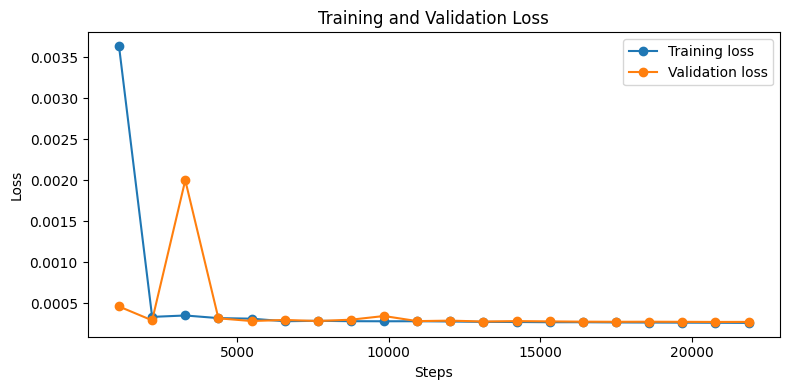

In [36]:
# Fetch the training and validation loss recorded each epoch
metric_names = ["train_multi_dataset_loss_epoch", "val_multi_dataset_loss_epoch"]

records = []
for metric in metric_names:
    for entry in client.get_metric_history(run_id, metric):
        records.append({"metric": metric, "epoch": entry.step, "loss": entry.value})

df = pd.DataFrame(records)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
for metric, label in zip(metric_names, ["Training loss", "Validation loss"]):
    subset = df[df["metric"] == metric].sort_values("epoch")
    ax.plot(subset["epoch"], subset["loss"], "-o", label=label)

ax.set_xlabel("Steps")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()


### Task 1: Change some key training variables and investigate the impact on scores the learning rate, number of channels, and max_epochs

First recreate the plots above with data from your own training runs. You will need to replace the run_id with the value in the output from your training run. This is printed around line 18 of the output, look for `Run id:`.

(Note we have also changed `tracking_uri` to `f"file://{os.getcwd()}/new_training_outputs/logs/mlflow"`, you do not need to change this again if looking at your own runs)


In [40]:
# Set the runId for the run you'd like to investigate.
run_id = "123f1bbcb0724159a3d92fd9c9afb6fe"

# Connect to the local MLflow tracking server (here a local directory) used by anemoi-training
tracking_uri = f"file://{os.getcwd()}/new_training_outputs/logs/mlflow"

client = mlflow.tracking.MlflowClient(tracking_uri=tracking_uri)

run = client.get_run(run_id)
print(f"Run name : {run.info.run_name}")
print(f"Run ID   : {run_id}")
print(f"\nAvailable metrics:")
for k in sorted(run.data.metrics.keys()):
    print(f"  {k}")


Run name : c59a1ae9-05a0-43fd-b71d-64e6c57c4045
Run ID   : 123f1bbcb0724159a3d92fd9c9afb6fe

Available metrics:
  epoch
  train_multi_dataset_loss_epoch
  val_data_mse_loss_scale_0
  val_data_mse_metric/data/all/1_scale_0
  val_data_mse_metric/data/sfc_sst/1_scale_0
  val_data_mse_metric/data/sst/1_scale_0
  val_multi_dataset_loss_epoch
  val_multi_dataset_loss_step


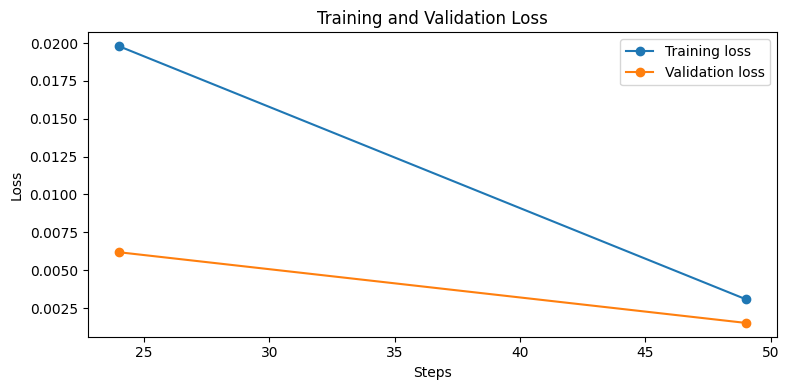

In [41]:

# Fetch the training and validation loss recorded each epoch
metric_names = ["train_multi_dataset_loss_epoch", "val_multi_dataset_loss_epoch"]

records = []
for metric in metric_names:
    for entry in client.get_metric_history(run_id, metric):
        records.append({"metric": metric, "epoch": entry.step, "loss": entry.value})

df = pd.DataFrame(records)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
for metric, label in zip(metric_names, ["Training loss", "Validation loss"]):
    subset = df[df["metric"] == metric].sort_values("epoch")
    ax.plot(subset["epoch"], subset["loss"], "-o", label=label)

ax.set_xlabel("Steps")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()


Next, adapt the training config (by directly editing the file ToySST.yaml in the training_configs directory) and retrain the model with any of the following (or your own ideas!). You can then plot some of the metrics from these runs by changing the run_id again, as discussed above, and see what impact your changes have on the training and validation loss:
   - Double or half the learning rate (`training: lr: rate`)
   - Provide the model with more data by increasing the batch size (`dataloader: limit_batches: training`)
   - Amend the size of the model, by increasing or decreasing the number of channels (`num_channels`)
   - Train the model for longer by increasing the number of iterations (`max_epochs` and/or `max_steps`)
   - Increase the number of samples considered within each training epoch, by increasing `data_loader: limit_batches: training`

**Questions**
- How does your loss change with these adaptions? 
- How much longer does the training take (per iteration and/or in total)?
- Does the relationshop between training and validation loss change? Are there any signs of overfitting? (you may need to carry out longer runs to be able to assess this)

***Note***:

You do not need to do the training in the notebook. Once the ToySST.yaml file has been edited, you can either rerun the training cell of the notebook, or you can run directly on the console with: 
```
anemoi-training train --config-path=PATH-TO-YOUR-CONFIG-FOLDER --config-name=ToySST
```

#### For a slightly more complex amendment
   - Remove the 2m temperature forcing field from the model (hint, you will need to consider both the `data` and `dataloader` parts of the configuration).
   How does this impact the training and validation scores?


### Inference of your model

Training is about letting the model learn the optimal set of weights to make predictions. Once these are learned, we can use the model to make predictions, this is referred to as inference.

To run inference on a pretrained model based on the above, go to the Jupyter notebook `inference_ToySST.ipynb`. Here you can also test running inference on the models you've trained yourselves.



In [42]:
import shutil

shutil.rmtree("new_training_outputs")
shutil.rmtree("pretrained_outputs")
shutil.rmtree("outputs")

In [43]:
!git status


On branch main
Your branch and 'origin/main' have diverged,
and have 1 and 1 different commits each, respectively.
  (use "git pull" if you want to integrate the remote branch with yours)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   training_ToySST.ipynb
	modified:   training_configs/ToySST.yaml

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	ToySSTDataset.zarr/
	training_configs/.ipynb_checkpoints/
	training_configs/diagnostics/.ipynb_checkpoints/
	training_configs/system/.ipynb_checkpoints/
	training_configs/system/hardware/.ipynb_checkpoints/
	training_configs/system/input/.ipynb_checkpoints/
	training_configs/system/output/.ipynb_checkpoints/

no changes added to commit (use "git add" and/or "git commit -a")


In [44]:
!git add training_ToySST.ipynb training_configs/ToySST.yaml